In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

seed= 42

In [103]:
train_df = pd.read_csv('train.csv')
test_df= pd.read_csv('test.csv')

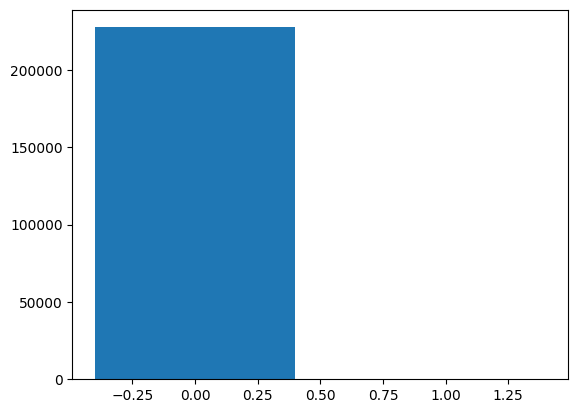

Class
0    227451
1       394
Name: count, dtype: int64

In [104]:
plt.bar(train_df['Class'].value_counts().index, train_df['Class'].value_counts().values)
plt.show()
train_df['Class'].value_counts()

In [105]:
# Subtask 1

answer1= []

legitimate_mean= train_df[train_df['Class'] == 0]['Amount'].mean()

answer1.append({
    'subtaskID': 1,
    'datapointID': 1,
    'answer': f"{len(train_df[(train_df['Class']== 1) & (train_df['Amount'] > legitimate_mean)]):.0f}"
})

In [106]:
# Subtask 2

frauds= train_df[train_df['Class']== 1]
features= ['Amount'] + [f'V{i}' for i in range(1, 29)]
X= frauds[features].values

mean_vec= np.mean(X, axis=0)
cov_matrix= np.cov(X, rowvar=False)

inv_cov= np.linalg.inv(cov_matrix)

def mahalanobis(x, mean, cov):
    diff= x- mean
    return np.sqrt(diff.T @ cov @ diff)

distances= np.array([mahalanobis(x,mean_vec, inv_cov) for x in X])

answer2= []

answer2.append({
    'subtaskID': 2,
    'datapointID': 1,
    'answer': round(distances.mean(), 2)
})

In [107]:
# Subtask 3
X_train, y_train= train_df.drop(columns=['id', 'Class']), train_df['Class']
X_test= test_df.drop(columns=['id'])

In [108]:
from sklearn.ensemble import RandomForestClassifier

model= RandomForestClassifier(n_estimators=100, random_state= seed)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [109]:
predictions= model.predict(X_test)

answer3= []

for id_, pred in zip(test_df['id'], predictions):
    answer3.append({
    'subtaskID': 3,
    'datapointID': id_,
    'answer': f'{pred:.0f}'
})

In [110]:
answer = pd.concat([pd.DataFrame(answer1), pd.DataFrame(answer2), pd.DataFrame(answer3)])
answer.to_csv("submission.csv", index= False)